# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [ ]:
df = pd.read_csv("../data/raw/IMDB Dataset.csv")

In [ ]:
df.shape

(50000, 2)

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [ ]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [ ]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

In [ ]:
df.head()

,review,sentiment,word_count
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


In [ ]:
df.groupby('sentiment')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.46456,164.947795,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.84932,177.497046,10.0,125.0,172.0,284.0,2470.0


In [ ]:
df.loc[df['word_count'].idxmax()]

review        Match 1: Tag Team Table Match Bubba Ray and Sp...
sentiment                                              positive
word_count                                                 2470
Name: 31481, dtype: object

In [ ]:
df.loc[df['word_count'].idxmin()]


review        Primary plot!Primary direction!Poor interpreta...
sentiment                                              negative
word_count                                                    4
Name: 28920, dtype: object

In [ ]:
df.head()

,review,sentiment,word_count,word count
0,One of the other reviewers has mentioned that ...,positive,307,307
1,A wonderful little production. <br /><br />The...,positive,162,162
2,I thought this was a wonderful way to spend ti...,positive,166,166
3,Basically there's a family where a little boy ...,negative,138,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,230


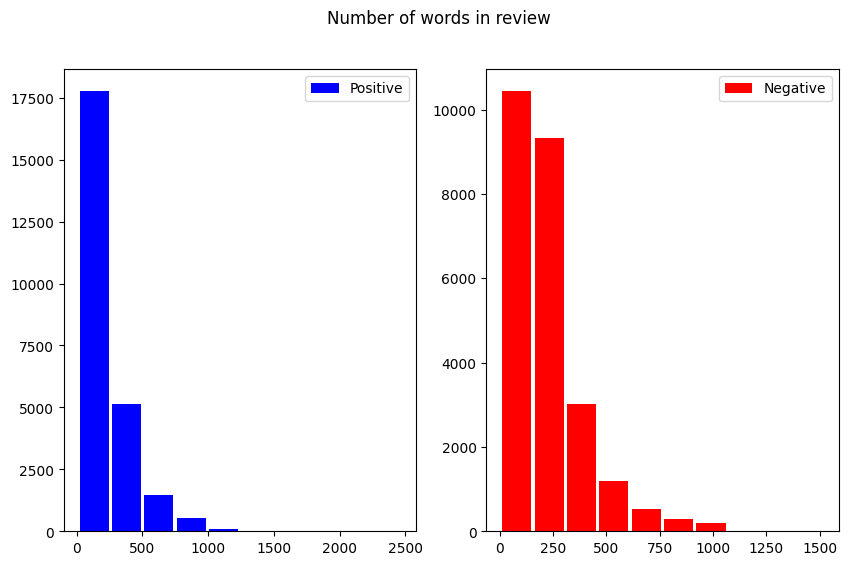

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['word count'], label='Positive', color='blue', rwidth=0.9);
ax[0].legend(loc='upper right');
ax[1].hist(df[df['sentiment'] == 'negative']['word count'], label='Negative', color='red', rwidth=0.9);
ax[1].legend(loc='upper right');
fig.suptitle("Number of words in review")
plt.show()

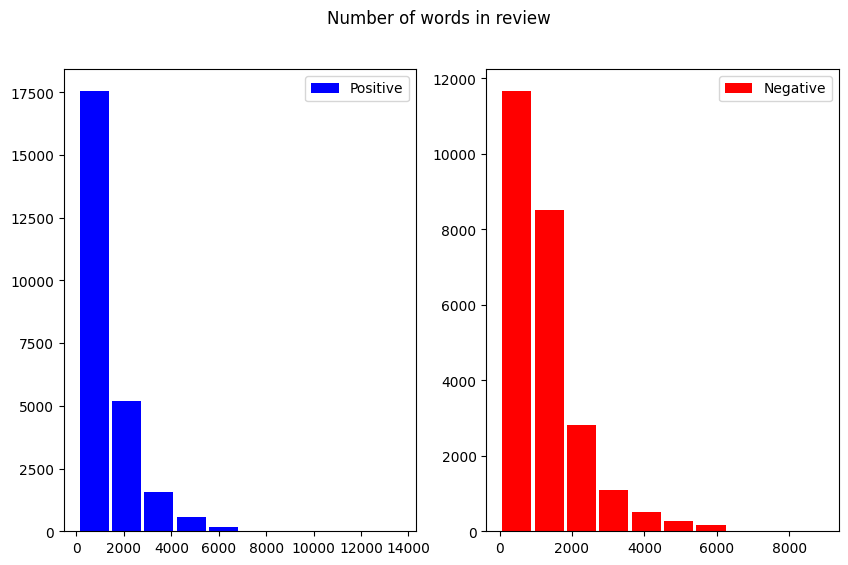

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['review'].str.len(), label='Positive', color='blue', rwidth=0.9);
ax[0].legend(loc='upper right');
ax[1].hist(df[df['sentiment'] == 'negative']['review'].str.len(), label='Negative', color='red', rwidth=0.9);
ax[1].legend(loc='upper right');
fig.suptitle("Number of words in review")
plt.show()

In [ ]:
pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

In [ ]:
count = Counter()
for text in pos['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('the', 291927),
 ('and', 165943),
 ('a', 155775),
 ('of', 149178),
 ('to', 128343),
 ('is', 108168),
 ('in', 90427),
 ('that', 62449),
 ('I', 62223),
 ('it', 53378),
 ('this', 51614),
 ('/><br', 48976),
 ('as', 46574),
 ('with', 43291),
 ('was', 42155)]

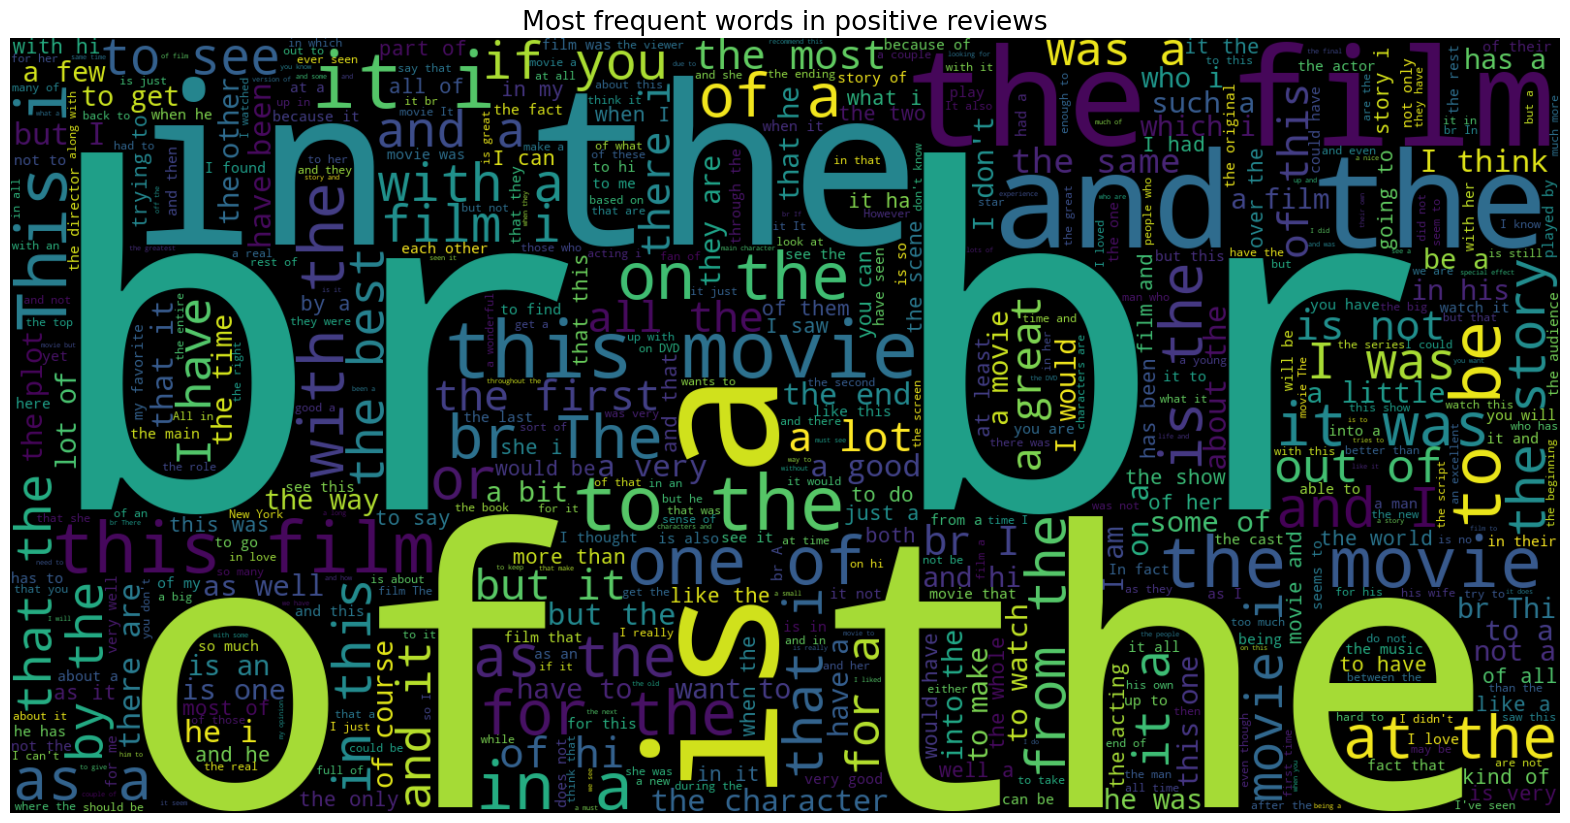

In [ ]:
text = ' '.join([word for word in pos['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(stopwords = set(), max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()

In [ ]:
count = Counter()
for text in neg['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('the', 276808),
 ('a', 151185),
 ('and', 135976),
 ('of', 134447),
 ('to', 133507),
 ('is', 94888),
 ('in', 79554),
 ('I', 70275),
 ('that', 64369),
 ('this', 62112),
 ('it', 54538),
 ('/><br', 51998),
 ('was', 50503),
 ('for', 39843),
 ('with', 39278)]

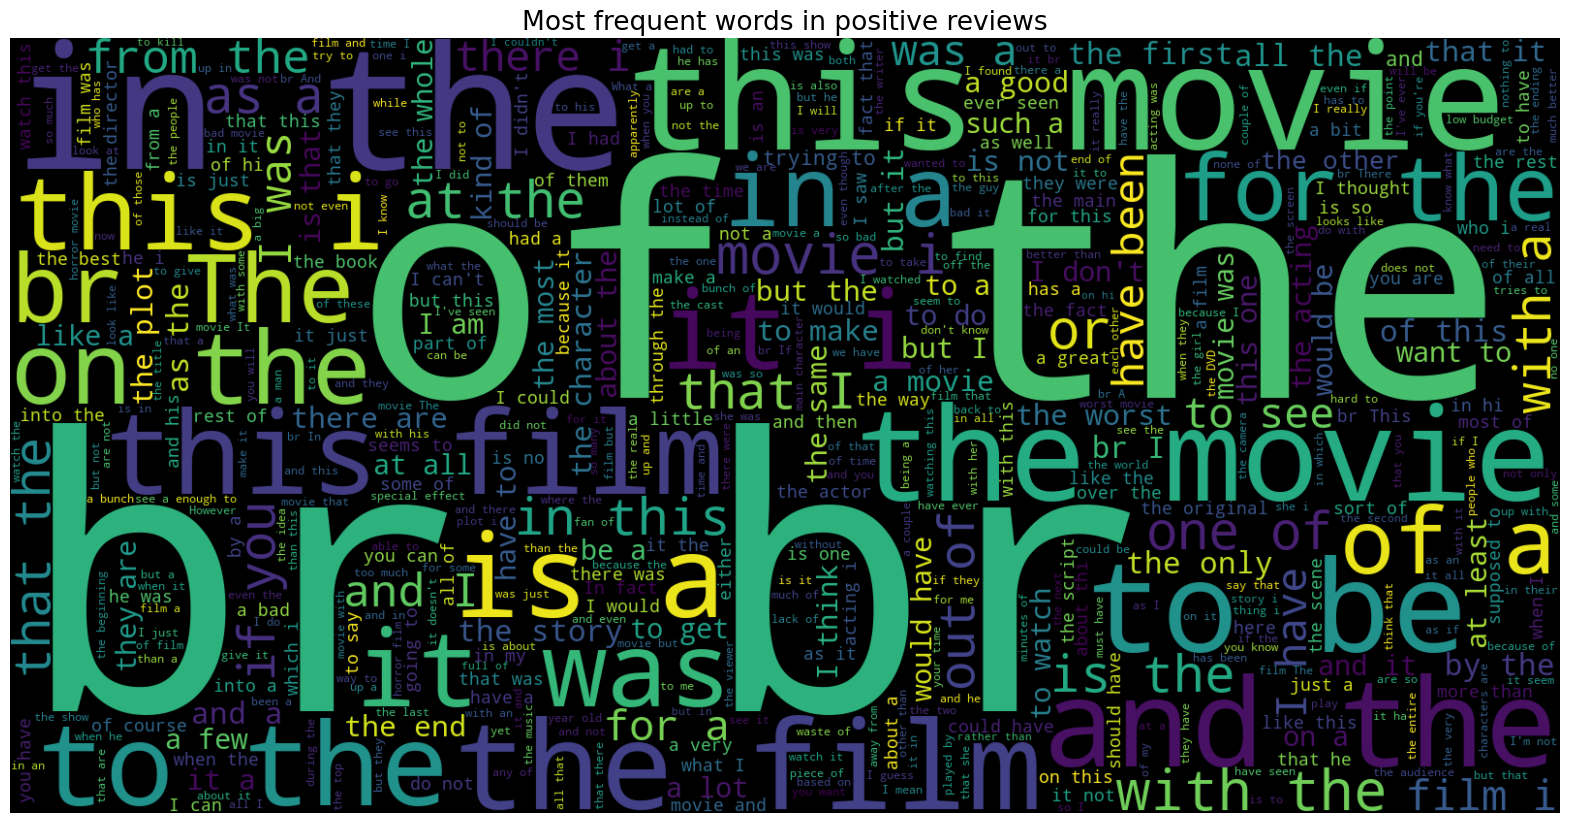

In [ ]:
text = ' '.join([word for word in neg['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(stopwords = set(), max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()